In [20]:
# ==========================================================
# Global Random Forest using MLForecast (Nixtla)
# ==========================================================

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Nixtla
# ==========================================================

from statsforecast import StatsForecast
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox

# ==========================================================
# Machine Learning
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Paths
# ==========================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

# ==========================================================
# Load Historical Sales Data
# ==========================================================

sales = pd.read_csv(

    processed_dir / "sales_clean.csv",

    parse_dates=["date"],

    low_memory=False

)

# ==========================================================
# Load Future Data
# ==========================================================

future = pd.read_csv(

    processed_dir / "future_clean.csv",

    parse_dates=["date"],

    low_memory=False

)

# ==========================================================
# Load Customer Forecast
# ==========================================================

customer_forecast = pd.read_csv(

    processed_dir / "future_customer_prediction_rf.csv",

    parse_dates=["ds"],

    low_memory=False

)
metadata = pd.read_csv(
    raw_dir / "metadata.csv"
)

print("=" * 60)
print("Historical Sales")
print("=" * 60)
print(sales.head())

print()

print("=" * 60)
print("Future Data")
print("=" * 60)
print(future.head())

print()

print("=" * 60)
print("Future Customer Forecast")
print("=" * 60)
print(customer_forecast.head())

Historical Sales
  store_id       date  sales  customers  open  promo state_holiday  \
0  store_1 2015-07-19      0          0     0      0             0   
1  store_2 2015-07-19      0          0     0      0             0   
2  store_3 2015-07-19      0          0     0      0             0   
3  store_4 2015-07-19      0          0     0      0             0   
4  store_5 2015-07-19      0          0     0      0             0   

   school_holiday store_type assortment  competition_distance  
0               0          c          a                1270.0  
1               0          a          a               14130.0  
2               0          a          c               24000.0  
3               0          a          a                7520.0  
4               0          a          c                2030.0  

Future Data
  store_id       date  open  promo  state_holiday  school_holiday  customers  \
0  store_1 2015-09-17   1.0      1              0               0        NaN   
1  st

In [21]:
# ==========================================================
# Global Random Forest using MLForecast (Nixtla)
# ==========================================================

import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Nixtla
# ==========================================================

from statsforecast import StatsForecast
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox

# ==========================================================
# Machine Learning
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

# ==========================================================
# Metrics
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Paths
# ==========================================================

processed_dir = Path("data/processed")
raw_dir = Path("data/raw")

# ==========================================================
# Load Historical Sales Data
# ==========================================================

sales = pd.read_csv(
    processed_dir / "sales_clean.csv",
    parse_dates=["date"],
    low_memory=False
)

# ==========================================================
# Load Future Data
# ==========================================================

future = pd.read_csv(
    processed_dir / "future_clean.csv",
    parse_dates=["date"],
    low_memory=False
)

# ==========================================================
# Load Customer Forecast
# ==========================================================

customer_forecast = pd.read_csv(
    processed_dir / "future_customer_prediction_rf.csv",
    parse_dates=["ds"],
    low_memory=False
)

# ==========================================================
# Remove Empty Customer Column
# ==========================================================

future = future.drop(columns=["customers"])

# ==========================================================
# Sort Data
# ==========================================================

sales = sales.sort_values(
    ["store_id", "date"]
).reset_index(drop=True)

future = future.sort_values(
    ["store_id", "date"]
).reset_index(drop=True)

customer_forecast = customer_forecast.sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

# ==========================================================
# Check Data
# ==========================================================

print("=" * 60)
print("Sales")
print("=" * 60)
print(sales.head())

print()

print("=" * 60)
print("Future")
print("=" * 60)
print(future.head())

print()

print("=" * 60)
print("Customer Forecast")
print("=" * 60)
print(customer_forecast.head())

Sales
  store_id       date  sales  customers  open  promo state_holiday  \
0  store_1 2013-01-07   7176        785     1      1             0   
1  store_1 2013-01-08   5580        654     1      1             0   
2  store_1 2013-01-09   5471        626     1      1             0   
3  store_1 2013-01-10   4892        615     1      1             0   
4  store_1 2013-01-11   4881        592     1      1             0   

   school_holiday store_type assortment  competition_distance  
0               1          c          a                1270.0  
1               1          c          a                1270.0  
2               1          c          a                1270.0  
3               1          c          a                1270.0  
4               1          c          a                1270.0  

Future
  store_id       date  open  promo  state_holiday  school_holiday store_type  \
0  store_1 2015-07-20   1.0      0              0               0          c   
1  store_1 2015-07-21

In [22]:
# ==========================================================
# Rename Columns for MLForecast
# ==========================================================

sales = sales.rename(
    columns={
        "store_id": "unique_id",
        "date": "ds",
        "sales": "y",
        "customers": "customer_prediction"
    }
)

future = future.rename(
    columns={
        "store_id": "unique_id",
        "date": "ds"
    }
)

# ==========================================================
# Merge Future Customer Forecast
# ==========================================================

future = future.merge(

    customer_forecast,

    on=[
        "unique_id",
        "ds"
    ],

    how="left"

)

# ==========================================================
# Check Customer Prediction
# ==========================================================

print("=" * 60)
print("Customer Prediction")
print("=" * 60)

print(
    future[
        [
            "unique_id",
            "ds",
            "customer_prediction"
        ]
    ].head()
)

print()

print("Missing customer predictions:")

print(
    future["customer_prediction"]
    .isna()
    .sum()
)

# ==========================================================
# Encode Categorical Features
# ==========================================================

state_holiday_map = {
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3,
    0: 0,
    0.0: 0
}

store_type_map = {
    "a": 0,
    "b": 1,
    "c": 2,
    "d": 3
}

assortment_map = {
    "a": 0,
    "b": 1,
    "c": 2
}

for df in [sales, future]:
    df["state_holiday"] = (
        df["state_holiday"]
        .replace(state_holiday_map)
        .fillna(0)
        .astype(int)
    )

    df["store_type"] = (
        df["store_type"]
        .map(store_type_map)
        .fillna(df["store_type"])
        .astype(int)
    )

    df["assortment"] = (
        df["assortment"]
        .map(assortment_map)
        .fillna(df["assortment"])
        .astype(int)
    )

# ==========================================================
# Create Additional Dynamic Features
# ==========================================================

# Weekend indicator
sales["is_weekend"] = (
        sales["ds"].dt.dayofweek >= 5
).astype(int)

future["is_weekend"] = (
        future["ds"].dt.dayofweek >= 5
).astype(int)

# Quarter
sales["quarter"] = sales["ds"].dt.quarter
future["quarter"] = future["ds"].dt.quarter

# ISO week number
sales["week_of_year"] = (
    sales["ds"]
    .dt.isocalendar()
    .week
    .astype(int)
)

future["week_of_year"] = (
    future["ds"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Promotion during weekends
sales["promo_weekend"] = (
        sales["promo"] *
        sales["is_weekend"]
)

future["promo_weekend"] = (
        future["promo"] *
        future["is_weekend"]
)


# Customer × Promotion
sales["customer_promo"] = (
        sales["customer_prediction"] *
        sales["promo"]
)

future["customer_promo"] = (
        future["customer_prediction"] *
        future["promo"]
)

# Customer × Weekend
sales["customer_weekend"] = (
        sales["customer_prediction"] *
        sales["is_weekend"]
)

future["customer_weekend"] = (
        future["customer_prediction"] *
        future["is_weekend"]
)

customer_mean = (
    sales
    .groupby("unique_id")["customer_prediction"]
    .mean()
)
sales["customer_ratio"] = (
    sales["customer_prediction"] /
    sales["unique_id"].map(customer_mean)
)

future["customer_ratio"] = (
    future["customer_prediction"] /
    future["unique_id"].map(customer_mean)
)

# ==========================================================
# Validate Features
# ==========================================================

print("=" * 60)
print("Additional Features")
print("=" * 60)

print(
    sales[
        [
            "unique_id",
            "ds",
            "customer_prediction",
            "promo",
            "customer_promo",
            "customer_weekend",
            "is_weekend",
            "quarter",
            "week_of_year",
            "promo_weekend"
        ]
    ].head()
)

print()

print(
    future[
        [
            "unique_id",
            "ds",
            "customer_prediction",
            "promo",
            "customer_promo",
            "customer_weekend",
            "is_weekend",
            "quarter",
            "week_of_year",
            "promo_weekend"
        ]
    ].head()
)

print()

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(sales.isna().sum())

print()

print(future.isna().sum())

Customer Prediction
  unique_id         ds  customer_prediction
0   store_1 2015-07-20              486.060
1   store_1 2015-07-21              446.065
2   store_1 2015-07-22              461.360
3   store_1 2015-07-23              470.705
4   store_1 2015-07-24              462.035

Missing customer predictions:
12168
Additional Features
  unique_id         ds  customer_prediction  promo  customer_promo  \
0   store_1 2013-01-07                  785      1             785   
1   store_1 2013-01-08                  654      1             654   
2   store_1 2013-01-09                  626      1             626   
3   store_1 2013-01-10                  615      1             615   
4   store_1 2013-01-11                  592      1             592   

   customer_weekend  is_weekend  quarter  week_of_year  promo_weekend  
0                 0           0        1             2              0  
1                 0           0        1             2              0  
2                 0   

In [23]:
print(future.columns.tolist())
print(customer_forecast.head())
future2 = future.merge(
    customer_forecast,
    on=["unique_id", "ds"],
    how="left",
    indicator=True
)

print(future2["_merge"].value_counts())

['unique_id', 'ds', 'open', 'promo', 'state_holiday', 'school_holiday', 'store_type', 'assortment', 'competition_distance', 'customer_prediction', 'is_weekend', 'quarter', 'week_of_year', 'promo_weekend', 'customer_promo', 'customer_weekend', 'customer_ratio']
  unique_id         ds  customer_prediction
0   store_1 2015-07-20              486.060
1   store_1 2015-07-21              446.065
2   store_1 2015-07-22              461.360
3   store_1 2015-07-23              470.705
4   store_1 2015-07-24              462.035
_merge
both          28392
left_only     12168
right_only        0
Name: count, dtype: int64


In [24]:
print("=" * 60)
print("Features Used for Training")
print("=" * 60)
print(sales.columns.tolist())

Features Used for Training
['unique_id', 'ds', 'y', 'customer_prediction', 'open', 'promo', 'state_holiday', 'school_holiday', 'store_type', 'assortment', 'competition_distance', 'is_weekend', 'quarter', 'week_of_year', 'promo_weekend', 'customer_promo', 'customer_weekend', 'customer_ratio']


In [25]:
# ==========================================================
# Hyperparameter Grid
# ==========================================================

parameter_grid = [

    {
        "name": "RF200_SQRT",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },

    {
        "name": "RF300_SQRT_Leaf5",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    }

]

# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

results = []

for params in parameter_grid:
    print("=" * 60)
    print(params["name"])
    print("=" * 60)

    # ------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------

    model = RandomForestRegressor(

        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        random_state=42,
        n_jobs=-1

    )

    # ------------------------------------------------------
    # MLForecast
    # ------------------------------------------------------

    fcst = MLForecast(

        models=[model],

        freq="D",

        lags=[
            1,
            7,
            14,
            21,
            28
        ],

        lag_transforms={

            7: [
                RollingMean(window_size=4)
            ],

            28: [
                RollingMean(window_size=2)
            ]

        },

        date_features=[
            "dayofweek",
            "month"
        ]

    )

    # ------------------------------------------------------
    # Rolling Forecast Origin Cross Validation
    # ------------------------------------------------------

    cv = fcst.cross_validation(

        df=sales,

        h=42,

        n_windows=3,

        refit=5,

        static_features=[]

    )

    prediction_col = cv.columns[-1]

    valid = cv["y"] > 0

    mae = mean_absolute_error(
        cv.loc[valid, "y"],
        cv.loc[valid, prediction_col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            cv.loc[valid, "y"],
            cv.loc[valid, prediction_col]
        )
    )

    mape = (
               np.abs(
                   (
                           cv.loc[valid, "y"]
                           - cv.loc[valid, prediction_col]
                   )
                   / cv.loc[valid, "y"]
               )
           ).mean() * 100

    results.append({

        "Model": params["name"],
        "Trees": params["n_estimators"],
        "Leaf": params["min_samples_leaf"],
        "Max Features": params["max_features"],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape

    })

    print(f"MAE :  {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAPE:  {mape:.2f}%")

# ==========================================================
# Hyperparameter Tuning Results
# ==========================================================

results = pd.DataFrame(results)

results = results.sort_values(
    by="MAPE",
    ascending=True
)

print(results)

results.to_csv(
    processed_dir / "rf_cv_results.csv",
    index=False
)

# ==========================================================
# Select Best Hyperparameters
# ==========================================================

best_result = results.iloc[0]

best_model = RandomForestRegressor(

    n_estimators=int(best_result["Trees"]),

    min_samples_leaf=int(best_result["Leaf"]),

    max_features=best_result["Max Features"],

    random_state=42,

    n_jobs=-1

)

# ==========================================================
# Train Final Model
# ==========================================================

final_fcst = MLForecast(

    models=[best_model],

    freq="D",

    lags=[
        1,
        7,
        14,
        21,
        28
    ],

    lag_transforms={

        7: [
            RollingMean(window_size=4)
        ],

        28: [
            RollingMean(window_size=2)
        ]

    },

    date_features=[
        "dayofweek",
        "month"
    ]

)

final_fcst.fit(

    sales,

    static_features=[]

)

print("=" * 60)
print("Best Model")
print("=" * 60)
print(best_result)
print()
print("Final model trained successfully.")
# ==========================================================
# Generate Features for the Final Model
# ==========================================================

features = final_fcst.preprocess(

    sales,

    static_features=[]

)

print("=" * 60)
print("Generated Features")
print("=" * 60)

print(features.head())

print(features.shape)

# ==========================================================
# Create Evaluation Dataset
# ==========================================================

eval_size = 42 * sales["unique_id"].nunique()

train_features = features.iloc[:-eval_size].copy()

test_features = features.iloc[-eval_size:].copy()

# Randomly sample observations to speed up permutation importance
test_features = test_features.sample(

    n=min(5000, len(test_features)),

    random_state=42

)

print("=" * 60)
print("Train Features:", train_features.shape)
print("Test Features :", test_features.shape)

RF200_SQRT
MAE :  567.37
RMSE:  808.99
MAPE:  7.82%
RF300_SQRT_Leaf5
MAE :  584.17
RMSE:  838.13
MAPE:  8.04%
              Model  Trees  Leaf Max Features         MAE        RMSE  \
0        RF200_SQRT    200     1         sqrt  567.371341  808.993246   
1  RF300_SQRT_Leaf5    300     5         sqrt  584.169702  838.131927   

       MAPE  
0  7.822213  
1  8.036313  
Best Model
Model           RF200_SQRT
Trees                  200
Leaf                     1
Max Features          sqrt
MAE             567.371341
RMSE            808.993246
MAPE              7.822213
Name: 0, dtype: object

Final model trained successfully.
Generated Features
   unique_id         ds       y  customer_prediction  open  promo  \
29   store_1 2013-02-05  6049.0                  678     1      1   
30   store_1 2013-02-06  6140.0                  693     1      1   
31   store_1 2013-02-07  5499.0                  675     1      1   
32   store_1 2013-02-08  5681.0                  630     1      1   
33   s

Generated Features
   unique_id         ds       y  customer_prediction  open  promo  \
29   store_1 2013-02-05  6049.0                  678     1      1   
30   store_1 2013-02-06  6140.0                  693     1      1   
31   store_1 2013-02-07  5499.0                  675     1      1   
32   store_1 2013-02-08  5681.0                  630     1      1   
33   store_1 2013-02-09  5370.0                  656     1      0   

    state_holiday  school_holiday  store_type  assortment  ...  \
29              0               0           2           0  ...   
30              0               0           2           0  ...   
31              0               0           2           0  ...   
32              0               0           2           0  ...   
33              0               0           2           0  ...   

    customer_ratio    lag1    lag7   lag14   lag21   lag28  \
29        1.449137  7032.0  3725.0  5720.0  3900.0  5580.0   
30        1.481197  6049.0  4601.0  5578.0  4

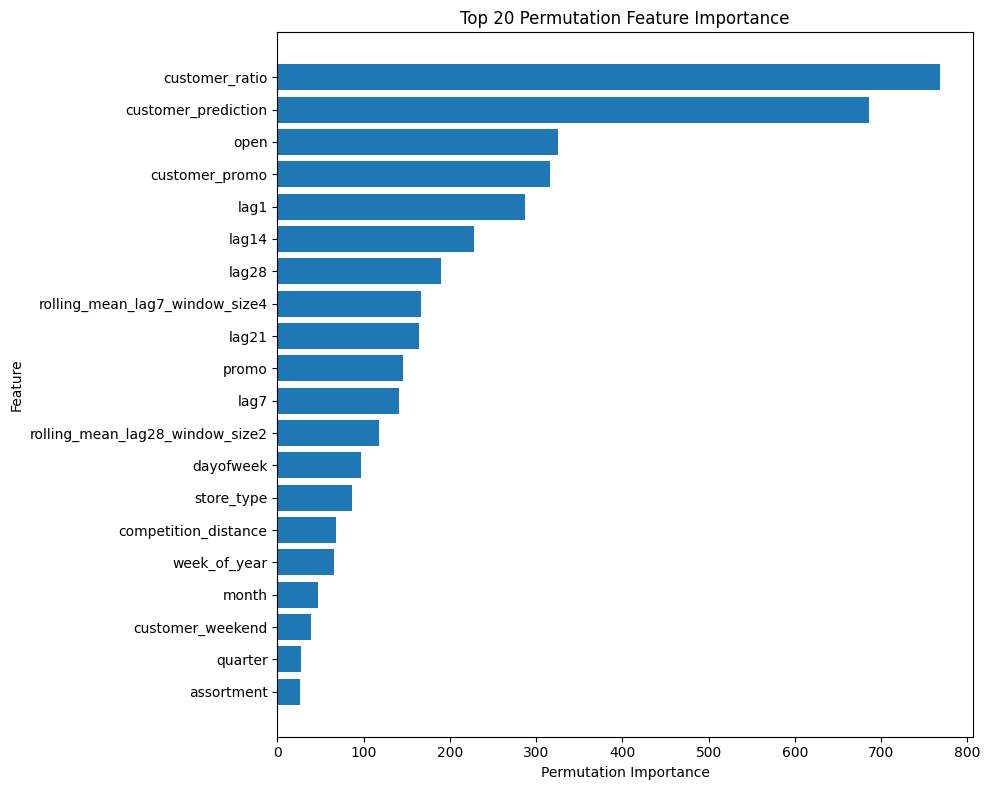

Permutation importance saved.


In [26]:
# ==========================================================
# Permutation Feature Importance
# ==========================================================

from sklearn.inspection import permutation_importance

# ==========================================================
# Generate Features from the Final Model
# ==========================================================

features = final_fcst.preprocess(

    sales,

    static_features=[]

)

print("=" * 60)
print("Generated Features")
print("=" * 60)

print(features.head())

print()

print("Feature Matrix Shape:")

print(features.shape)

# ==========================================================
# Create Evaluation Dataset
# ==========================================================

# Use the last 42 days for evaluation
eval_size = 42 * sales["unique_id"].nunique()

train_features = features.iloc[:-eval_size].copy()

test_features = features.iloc[-eval_size:].copy()

# Randomly sample observations to reduce computation time
test_features = test_features.sample(

    n=min(1000, len(test_features)),

    random_state=42

)

print("=" * 60)
print("Evaluation Dataset")
print("=" * 60)

print("Train Features:", train_features.shape)

print("Test Features :", test_features.shape)

# ==========================================================
# Prepare Test Data
# ==========================================================

X_test = test_features.drop(

    columns=[

        "unique_id",

        "ds",

        "y"

    ]

)

y_test = test_features["y"]

print()

print("X_test Shape:")

print(X_test.shape)

# ==========================================================
# Extract Final Random Forest
# ==========================================================

rf = list(final_fcst.models_.values())[0]

print("=" * 60)
print("Final Random Forest")
print("=" * 60)

print(rf)

# ==========================================================
# Permutation Importance
# ==========================================================

perm = permutation_importance(

    estimator=rf,

    X=X_test,

    y=y_test,

    scoring="neg_mean_absolute_error",

    n_repeats=2,

    random_state=42,

    n_jobs=1

)

print()

print("Permutation importance completed.")

# ==========================================================
# Create Importance Table
# ==========================================================

importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance": perm.importances_mean

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

).reset_index(drop=True)

print("=" * 60)
print("Top 20 Important Features")
print("=" * 60)

print(importance.head(20))

# ==========================================================
# Plot Top 20 Features
# ==========================================================

top20 = importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(

    top20["Feature"],

    top20["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Permutation Importance")

plt.ylabel("Feature")

plt.title("Top 20 Permutation Feature Importance")

plt.tight_layout()

plt.show()

# ==========================================================
# Save Results
# ==========================================================

importance.to_csv(

    processed_dir / "permutation_importance.csv",

    index=False

)

print("=" * 60)
print("Permutation importance saved.")
print("=" * 60)

In [27]:
# ==========================================================
# Predict Future 42 Days
# ==========================================================

future_forecast = final_fcst.predict(

    h=42,

    X_df=future

)

prediction_col = future_forecast.columns[-1]

future_forecast = future_forecast.rename(

    columns={
        prediction_col: "sales_prediction"
    }

)

print("=" * 60)
print("Future Forecast")
print("=" * 60)

print(future_forecast.head())

print()

print("Forecast Shape:")

print(future_forecast.shape)

# ==========================================================
# Create Final Forecast Dataset
# ==========================================================

future_result = future[
    [
        "unique_id",
        "ds",
        "customer_prediction"
    ]
].merge(

    future_forecast,

    on=[
        "unique_id",
        "ds"
    ],

    how="left"

)

print()

print("=" * 60)
print("Final Forecast")
print("=" * 60)

print(future_result.head())

# ==========================================================
# Keep Forecast Until 2015-08-29
# ==========================================================

future_result = future_result[
    future_result["ds"] < "2015-08-30"
].copy()

print("=" * 60)
print("Forecast Period")
print("=" * 60)

print(
    future_result["ds"].min(),
    "to",
    future_result["ds"].max()
)

print(f"Rows: {len(future_result):,}")

# ==========================================================
# Save Forecast
# ==========================================================

output_file = processed_dir / "future_prediction_rf.csv"

future_result.to_csv(
    output_file,
    index=False
)

print("=" * 60)
print("Forecast saved successfully.")
print("=" * 60)

print(output_file)

Future Forecast
  unique_id         ds  sales_prediction
0   store_1 2015-07-20          3727.445
1   store_1 2015-07-21          3443.395
2   store_1 2015-07-22          3508.745
3   store_1 2015-07-23          3577.855
4   store_1 2015-07-24          3617.725

Forecast Shape:
(28392, 3)

Final Forecast
  unique_id         ds  customer_prediction  sales_prediction
0   store_1 2015-07-20              486.060          3727.445
1   store_1 2015-07-21              446.065          3443.395
2   store_1 2015-07-22              461.360          3508.745
3   store_1 2015-07-23              470.705          3577.855
4   store_1 2015-07-24              462.035          3617.725
Forecast Period
2015-07-20 00:00:00 to 2015-08-29 00:00:00
Rows: 27,716
Forecast saved successfully.
data\processed\future_prediction_rf.csv


In [28]:
# ==========================================================
# Weekly Forecast Aggregation
# ==========================================================
# Aggregate every consecutive 7 days into one forecast week
# ==========================================================

weekly_data = future_result.copy()

# ----------------------------------------------------------
# Create Forecast Week
# ----------------------------------------------------------

weekly_data = weekly_data.sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

weekly_data["forecast_week"] = (

        weekly_data

        .groupby("unique_id")

        .cumcount()

        // 7

        + 1

)

print("=" * 60)
print("Forecast Weeks")
print("=" * 60)

print(
    weekly_data[
        [
            "unique_id",
            "ds",
            "forecast_week"
        ]
    ].head(15)
)

# ==========================================================
# Store Weekly Forecast
# ==========================================================

store_weekly = (

    weekly_data

    .groupby(

        [
            "unique_id",
            "forecast_week"
        ],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Store Weekly Forecast")
print("=" * 60)

print(store_weekly.head())

# ==========================================================
# Merge Metadata
# ==========================================================

metadata_rf = metadata.rename(

    columns={

        "store_id": "unique_id"

    }

)

store_weekly = store_weekly.merge(

    metadata_rf[
        [
            "unique_id",
            "store_type"
        ]
    ],

    how="left",

    on="unique_id"

)

# ==========================================================
# Store Type Weekly Forecast
# ==========================================================

store_type_weekly = (

    store_weekly

    .groupby(

        [
            "store_type",
            "forecast_week"
        ],

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Store Type Weekly Forecast")
print("=" * 60)

print(store_type_weekly)

# ==========================================================
# Company Weekly Forecast
# ==========================================================

company_weekly = (

    store_weekly

    .groupby(

        "forecast_week",

        as_index=False

    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Company Weekly Forecast")
print("=" * 60)

print(company_weekly)

# ==========================================================
# Total Forecast for the Next 6 Weeks
# ==========================================================

company_total = company_weekly["sales_prediction"].sum()

print("=" * 60)
print("Total Sales Forecast")
print("=" * 60)

print(f"6-Week Total Sales: {company_total:,.2f}")

# ==========================================================
# COO Focus:
# First Two Weeks
# ==========================================================

print("=" * 60)
print("Forecast for the Next Two Weeks")
print("=" * 60)

print(company_weekly.head(2))

# ==========================================================
# Save Results
# ==========================================================

store_weekly.to_csv(
    processed_dir / "store_weekly_forecast_rf.csv",
    index=False
)

store_type_weekly.to_csv(
    processed_dir / "store_type_weekly_forecast_rf.csv",
    index=False
)

company_weekly.to_csv(
    processed_dir / "company_weekly_forecast_rf.csv",
    index=False
)

print("=" * 60)
print("Weekly forecasts saved successfully.")
print("=" * 60)

Forecast Weeks
   unique_id         ds  forecast_week
0    store_1 2015-07-20              1
1    store_1 2015-07-21              1
2    store_1 2015-07-22              1
3    store_1 2015-07-23              1
4    store_1 2015-07-24              1
5    store_1 2015-07-25              1
6    store_1 2015-07-26              1
7    store_1 2015-07-27              2
8    store_1 2015-07-28              2
9    store_1 2015-07-29              2
10   store_1 2015-07-30              2
11   store_1 2015-07-31              2
12   store_1 2015-08-01              2
13   store_1 2015-08-02              2
14   store_1 2015-08-03              3
Store Weekly Forecast
  unique_id  forecast_week  sales_prediction
0   store_1              1         21681.355
1   store_1              2         28624.885
2   store_1              3         27145.375
3   store_1              4         21828.790
4   store_1              5         26256.375
Store Type Weekly Forecast
   store_type  forecast_week  sales_predic

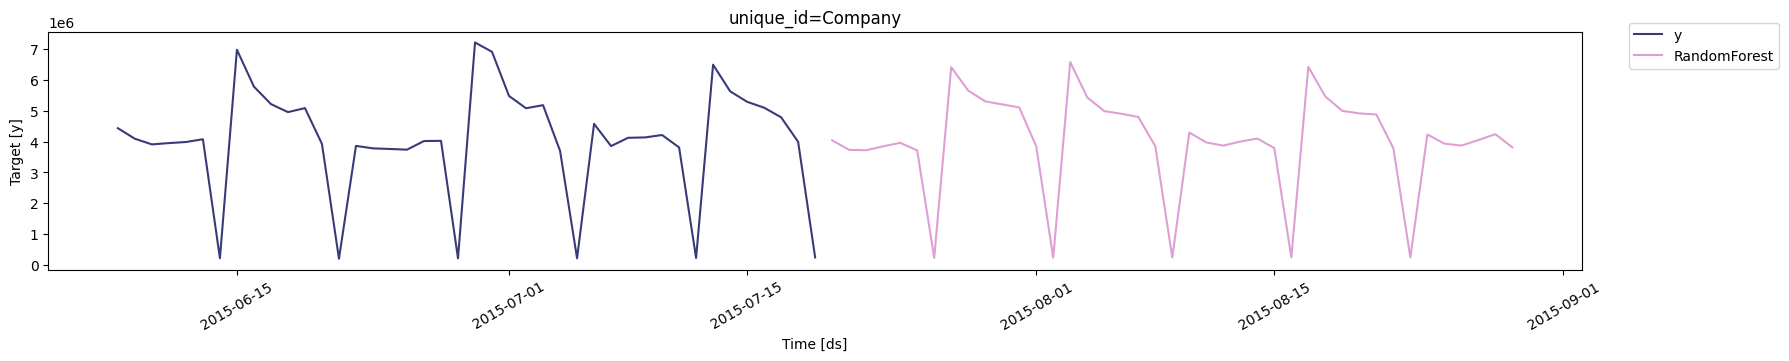

In [29]:
# ==========================================================
# Company Historical Sales
# ==========================================================

company_history = (

    sales
    .groupby("ds", as_index=False)["y"]
    .sum()

)

company_history["unique_id"] = "Company"

company_history = company_history[
    ["unique_id", "ds", "y"]
]

# Keep only the last 42 historical days
company_history = company_history.tail(42)

# ==========================================================
# Company Forecast
# ==========================================================

company_forecast = (

    future_result
    .groupby("ds", as_index=False)["sales_prediction"]
    .sum()

)

company_forecast["unique_id"] = "Company"

company_forecast = company_forecast.rename(
    columns={
        "sales_prediction": "RandomForest"
    }
)

company_forecast = company_forecast[
    ["unique_id", "ds", "RandomForest"]
]

# ==========================================================
# Plot
# ==========================================================

StatsForecast.plot(
    df=company_history,
    forecasts_df=company_forecast
)

Daily Company Forecast
          ds  sales_prediction
0 2015-07-20       4041089.635
1 2015-07-21       3731512.040
2 2015-07-22       3719440.870
3 2015-07-23       3846851.130
4 2015-07-24       3958989.580
(41, 2)
Weekly Forecast
   sales_prediction  week  Sales_Million
0      2.323569e+07     1      23.235695
1      3.178106e+07     2      31.781063
2      3.080133e+07     3      30.801326
3      2.426294e+07     4      24.262941
4      3.071198e+07     5      30.711976
5      2.414014e+07     6      24.140136


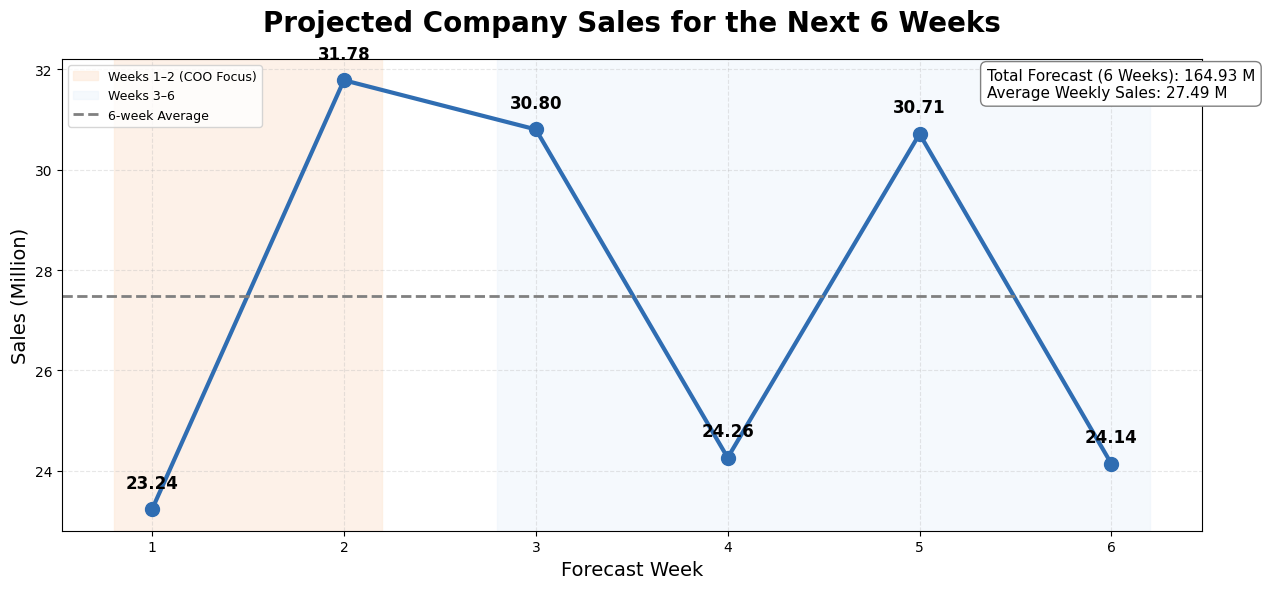

In [30]:
# ==========================================================
# Company Weekly Forecast
# ==========================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------
# Daily Company Forecast
# ----------------------------------------------------------

daily_company = (

    future_result

    .groupby(
        "ds",
        as_index=False
    )["sales_prediction"]

    .sum()

)

print("=" * 60)
print("Daily Company Forecast")
print("=" * 60)

print(daily_company.head())

print(daily_company.shape)

# ----------------------------------------------------------
# Weekly Forecast
# ----------------------------------------------------------

weekly_forecast = (

    daily_company

    .groupby(

        np.arange(len(daily_company)) // 7,

        as_index=False

    )["sales_prediction"]

    .sum()

)

weekly_forecast["week"] = np.arange(1, 7)

weekly_forecast["Sales_Million"] = (

    weekly_forecast["sales_prediction"] / 1_000_000

)

print("=" * 60)
print("Weekly Forecast")
print("=" * 60)

print(weekly_forecast)

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

weekly_forecast.to_csv(

    processed_dir / "weekly_forecast_rf.csv",

    index=False

)

# ==========================================================
# Weekly Forecast Dashboard
# ==========================================================

import matplotlib.pyplot as plt

weekly_sales = weekly_forecast["Sales_Million"]

weeks = weekly_forecast["week"]

total_sales = weekly_sales.sum()

average_sales = weekly_sales.mean()

fig, ax = plt.subplots(
    figsize=(13,6)
)

# ----------------------------------------------------------
# Background
# ----------------------------------------------------------

ax.axvspan(
    0.8,
    2.2,
    color="#FDE9D9",
    alpha=0.6,
    label="Weeks 1–2 (COO Focus)"
)

ax.axvspan(
    2.8,
    6.2,
    color="#EAF2FB",
    alpha=0.45,
    label="Weeks 3–6"
)

# ----------------------------------------------------------
# Forecast Line
# ----------------------------------------------------------

ax.plot(
    weeks,
    weekly_sales,
    color="#2F6DB2",
    linewidth=3,
    marker="o",
    markersize=10
)

# ----------------------------------------------------------
# Average Line
# ----------------------------------------------------------

ax.axhline(
    average_sales,
    color="gray",
    linestyle="--",
    linewidth=2,
    label="6-week Average"
)

# ----------------------------------------------------------
# Labels
# ----------------------------------------------------------

offset = (
    weekly_sales.max()
    - weekly_sales.min()
) * 0.05

for x, y in zip(weeks, weekly_sales):

    ax.text(
        x,
        y + offset,
        f"{y:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

# ----------------------------------------------------------
# Statistics Box
# ----------------------------------------------------------

stats = (
    f"Total Forecast (6 Weeks): {total_sales:.2f} M\n"
    f"Average Weekly Sales: {average_sales:.2f} M"
)

ax.text(
    5.35,
    weekly_sales.max() + 0.25,
    stats,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        boxstyle="round,pad=0.4"
    )
)

# ----------------------------------------------------------
# Layout
# ----------------------------------------------------------

ax.set_title(
    "Projected Company Sales for the Next 6 Weeks",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Forecast Week",
    fontsize=14
)

ax.set_ylabel(
    "Sales (Million)",
    fontsize=14
)

ax.set_xticks(weeks)

ax.grid(
    alpha=0.3,
    linestyle="--"
)

ax.legend(
    loc="upper left",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    processed_dir / "weekly_forecast_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top 5 Stores
     unique_id  sales_prediction
63   store_156        832069.045
639  store_675        772986.305
271  store_343        716230.175
55   store_149        621039.050
383  store_444        602386.365


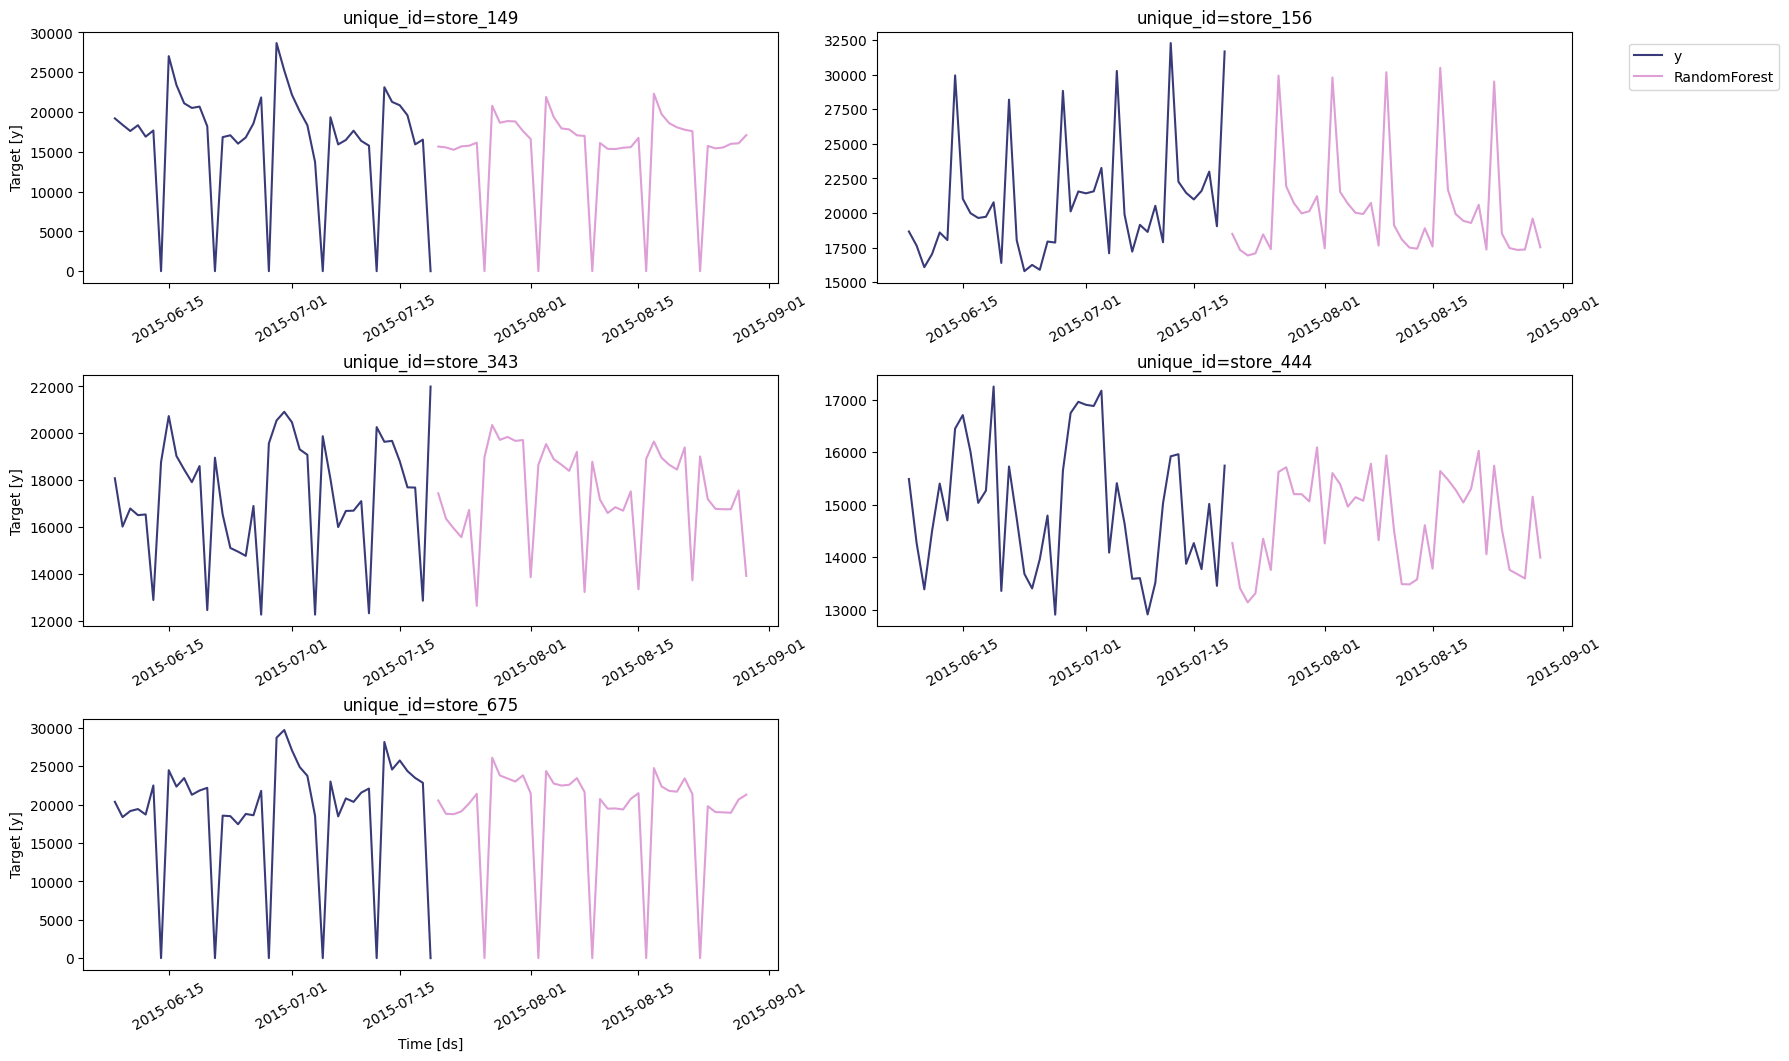

In [31]:
# ==========================================================
# Top 5 Stores Forecast (Nixtla)
# ==========================================================

# ----------------------------------------------------------
# Find Top 5 Stores
# ----------------------------------------------------------

top5_stores = (

    future_result

    .groupby(
        "unique_id",
        as_index=False
    )["sales_prediction"]

    .sum()

    .sort_values(
        "sales_prediction",
        ascending=False
    )

    .head(5)

)

print("=" * 60)
print("Top 5 Stores")
print("=" * 60)

print(top5_stores)

# ----------------------------------------------------------
# Historical Data
# ----------------------------------------------------------

history_top5 = (

    sales

    .merge(

        top5_stores[
            ["unique_id"]
        ],

        on="unique_id"

    )

)

history_top5 = history_top5[
    [
        "unique_id",
        "ds",
        "y"
    ]
]

# Keep only the last 42 historical days
history_top5 = (

    history_top5

    .sort_values(
        [
            "unique_id",
            "ds"
        ]
    )

    .groupby("unique_id")

    .tail(42)

)

# ----------------------------------------------------------
# Forecast Data
# ----------------------------------------------------------

forecast_top5 = (

    future_result

    .merge(

        top5_stores[
            ["unique_id"]
        ],

        on="unique_id"

    )

)

forecast_top5 = forecast_top5.rename(

    columns={

        "sales_prediction": "RandomForest"

    }

)

forecast_top5 = forecast_top5[
    [
        "unique_id",
        "ds",
        "RandomForest"
    ]
]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

StatsForecast.plot(

    df=history_top5,

    forecasts_df=forecast_top5

)